# Notebook 4: Model Comparison (Week 5)

The goal for Week 5 is to see whether a Decision Tree or Random Forest beats the Linear Regression baseline on test R squared, and to write down what each model's behavior actually looks like, not just its final score.

The baseline is retrained here rather than reused from notebook 3. This keeps the comparison apples to apples, since all three models go through the exact same preprocessing pipeline defined in this notebook, and it means this notebook has no dependency on a saved model object from notebook 3 still existing.

In [26]:
import os
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

RANDOM_STATE = 42  # fixed for reproducibility across DecisionTree and RandomForest

## 1. Load Preprocessed Data

Same three files as notebook 3. SaleYearMonth comes back as a plain string after the CSV round trip. It is excluded from the model features below, same as before.

In [17]:
os.chdir(os.path.expanduser("~/Desktop/CAPropPredictor"))

housing_train_m1 = pd.read_csv("CRMLSCleaned/housingtrainm1.csv")
housing_val_m1 = pd.read_csv("CRMLSCleaned/housingvalm1.csv")
housing_test_m1 = pd.read_csv("CRMLSCleaned/housingtestm1.csv")

print(f"train: {housing_train_m1.shape}")
print(f"val:   {housing_val_m1.shape}")
print(f"test:  {housing_test_m1.shape}")

train: (128340, 25)
val:   (11890, 25)
test:  (11902, 25)


## 2. Shared Feature List and Preprocessing

Same feature columns and same ColumnTransformer logic as notebook 3. Written as a function here so each model gets its own fresh, unfitted copy of the preprocessor rather than three models sharing one fitted transformer, which would leak information about how each model was trained into the others.

In [18]:
non_feature_columns = ["ClosePrice", "SaleYearMonth"]

numeric_feature_columns = [
    "Latitude", "Longitude",
    "ViewYN", "PoolPrivateYN", "AttachedGarageYN", "FireplaceYN", "NewConstructionYN",
    "ParkingTotal", "BathroomsTotalInteger", "BedroomsTotal", "MainLevelBedrooms", "GarageSpaces",
    "LivingArea", "LotSizeSquareFeet", "AssociationFee", "YearBuilt",
    "Levels", "Stories",
]
categorical_feature_columns = ["City", "CountyOrParish", "MLSAreaMajor", "HighSchoolDistrict", "Flooring"]
feature_columns = numeric_feature_columns + categorical_feature_columns

assert set(feature_columns) == set(housing_train_m1.columns) - set(non_feature_columns), (
    "feature_columns doesn't match housing_train_m1's actual columns, check for a typo."
)

def make_preprocessor():
    return ColumnTransformer(transformers=[
        ("numeric", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), numeric_feature_columns),
        ("categorical", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_feature_columns),
    ])

X_train, y_train = housing_train_m1[feature_columns], housing_train_m1["ClosePrice"]
X_val, y_val = housing_val_m1[feature_columns], housing_val_m1["ClosePrice"]
X_test, y_test = housing_test_m1[feature_columns], housing_test_m1["ClosePrice"]

def evaluate(pipeline, X, y, label):
    preds = pipeline.predict(X)
    r2 = r2_score(y, preds)
    mae = mean_absolute_error(y, preds)
    mape = mean_absolute_percentage_error(y, preds)
    mdape = np.median(np.abs((y - preds) / y))
    print(f"{label:>5s}: R2={r2:.4f}  MAE=${mae:,.0f}  MAPE={mape:.2%}  MdAPE={mdape:.2%}")
    return {"r2": r2, "mae": mae, "mape": mape, "mdape": mdape}

results = {}

## 3. Baseline: Linear Regression

Retrained here for the reasons stated at the top. Numbers should match notebook 3 assuming the same CSVs and the same feature list.

In [19]:
lr_pipeline = Pipeline([
    ("preprocess", make_preprocessor()),
    ("model", LinearRegression()),
])
lr_pipeline.fit(X_train, y_train)

print("Linear Regression:")
results["LinearRegression"] = {
    "train": evaluate(lr_pipeline, X_train, y_train, "train"),
    "val": evaluate(lr_pipeline, X_val, y_val, "val"),
    "test": evaluate(lr_pipeline, X_test, y_test, "test"),
}

Linear Regression:
train: R2=0.8266  MAE=$232,591  MAPE=22.25%  MdAPE=15.90%
  val: R2=0.8223  MAE=$247,420  MAPE=22.98%  MdAPE=16.19%
 test: R2=0.8217  MAE=$248,884  MAPE=22.68%  MdAPE=16.10%


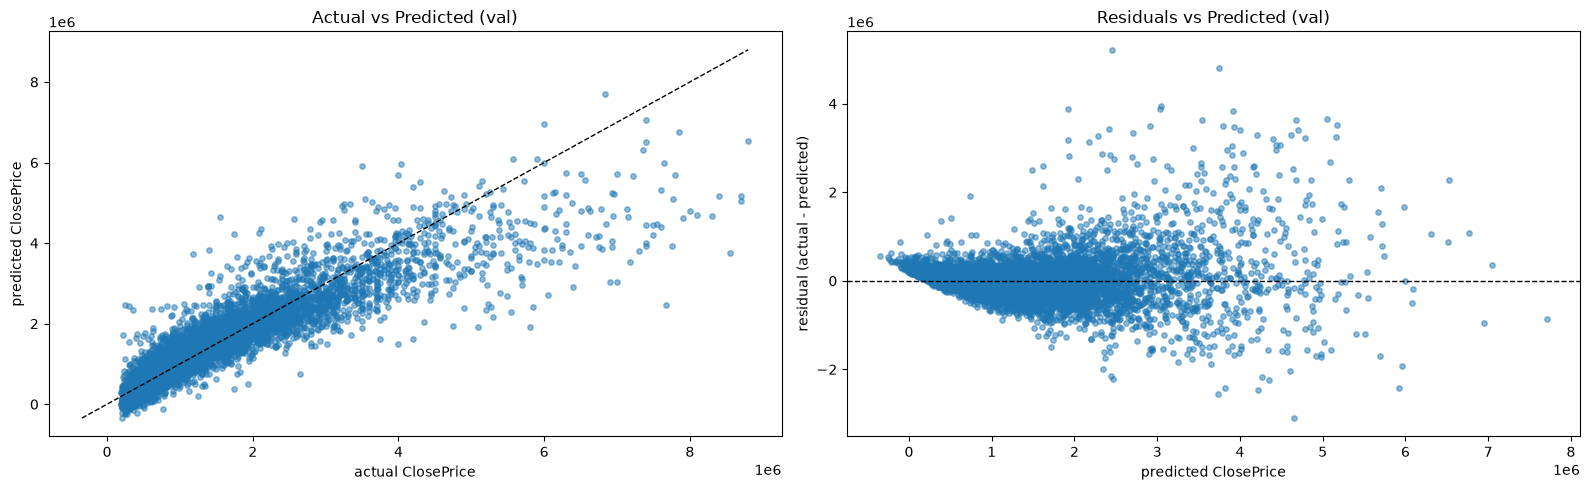

In [28]:

preds = lr_pipeline.predict(X_val)
residuals = y_val - preds

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Actual vs Predicted:
axes[0].scatter(y_val, preds, alpha=0.5, s=15)
lims = [min(y_val.min(), preds.min()), max(y_val.max(), preds.max())]
axes[0].plot(lims, lims, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("actual ClosePrice")
axes[0].set_ylabel("predicted ClosePrice")
axes[0].set_title("Actual vs Predicted (val)")

# Residuals vs Predicted:
axes[1].scatter(preds, residuals, alpha=0.5, s=15)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("predicted ClosePrice")
axes[1].set_ylabel("residual (actual - predicted)")
axes[1].set_title("Residuals vs Predicted (val)")

plt.tight_layout()
plt.show()

## 4. Decision Tree

A single decision tree splits the data recursively on feature thresholds, trying to make each resulting group as internally consistent in price as possible. Unlike Linear Regression, it does not assume the relationship between a feature and price is additive or linear, so it can pick up interactions and non-linear effects on its own, for example a large house mattering more in some neighborhoods than others, without that interaction being written into the feature list by hand.

The known weakness to watch for here is overfitting. Left unconstrained, a single tree can keep splitting until each leaf holds only a handful of training rows, effectively memorizing the training set rather than learning a generalizable pattern. This means train R squared alone is not a trustworthy signal for this model. A tree scoring near perfect on train and noticeably worse on validation is not a bug, it is the expected failure mode of this specific algorithm, and it is exactly why the validation and test scores matter more here than the train score.

In [21]:
dt_pipeline = Pipeline([
    ("preprocess", make_preprocessor()),
    ("model", DecisionTreeRegressor(random_state=RANDOM_STATE)),
])
dt_pipeline.fit(X_train, y_train)

print("Decision Tree:")
results["DecisionTree"] = {
    "train": evaluate(dt_pipeline, X_train, y_train, "train"),
    "val": evaluate(dt_pipeline, X_val, y_val, "val"),
    "test": evaluate(dt_pipeline, X_test, y_test, "test"),
}

Decision Tree:
train: R2=0.9999  MAE=$180  MAPE=0.02%  MdAPE=0.00%
  val: R2=0.7702  MAE=$234,929  MAPE=17.13%  MdAPE=11.11%
 test: R2=0.7824  MAE=$232,524  MAPE=16.91%  MdAPE=11.19%


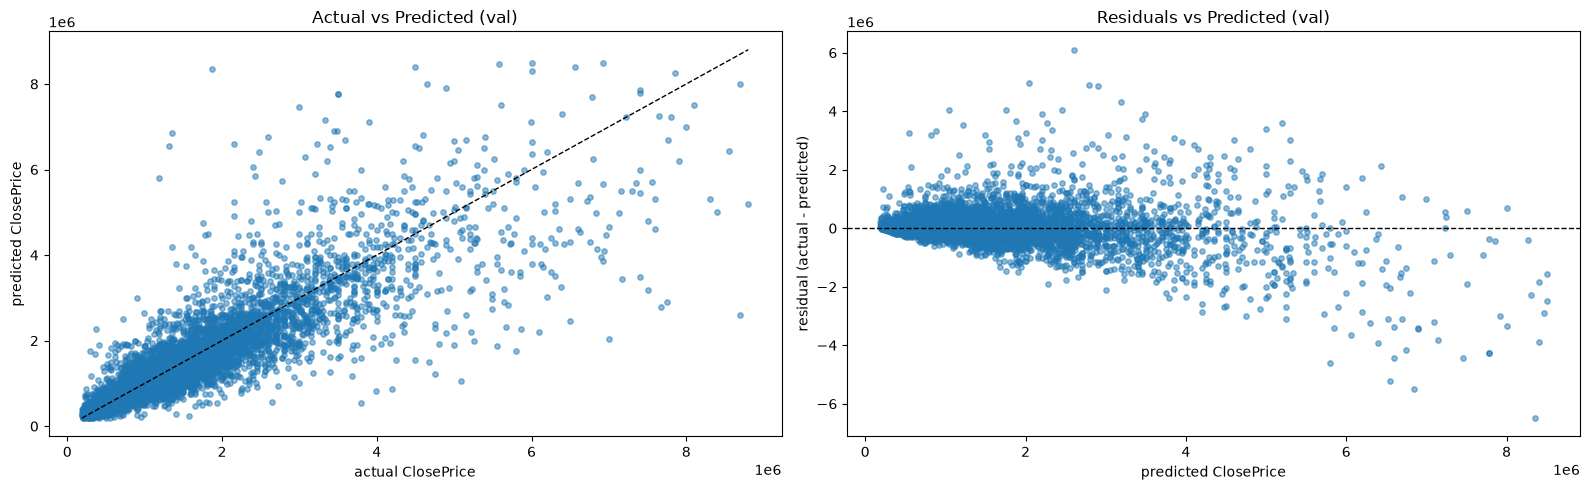

In [30]:
preds = dt_pipeline.predict(X_val)
residuals = y_val - preds

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Actual vs Predicted
axes[0].scatter(y_val, preds, alpha=0.5, s=15)
lims = [min(y_val.min(), preds.min()), max(y_val.max(), preds.max())]
axes[0].plot(lims, lims, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("actual ClosePrice")
axes[0].set_ylabel("predicted ClosePrice")
axes[0].set_title("Actual vs Predicted (val)")

# Residuals vs Predicted
axes[1].scatter(preds, residuals, alpha=0.5, s=15)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("predicted ClosePrice")
axes[1].set_ylabel("residual (actual - predicted)")
axes[1].set_title("Residuals vs Predicted (val)")

plt.tight_layout()
plt.show()

## 5. Random Forest

Random Forest trains many decision trees, each on a bootstrapped sample of the training rows and each considering only a random subset of features at every split, then averages their predictions. Each individual tree is still prone to the same overfitting behavior described above, but the trees end up decorrelated from each other because of the random sampling, so their individual errors tend to cancel out when averaged rather than compound. This is why Random Forest is expected to keep the non-linear, interaction-capturing strength of a single tree while closing most of the train to validation gap that a single tree shows.

The tradeoff is that a forest of hundreds of trees cannot be read or explained the way a single tree can. It is also slower to train and to predict with, and introduces its own hyperparameters, mainly the number of trees and how deep each one is allowed to grow, that are left at reasonable defaults here rather than tuned. Tuning those, if needed, is validation set work, not something to do against test.

In [22]:
rf_pipeline = Pipeline([
    ("preprocess", make_preprocessor()),
    ("model", RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
])
rf_pipeline.fit(X_train, y_train)

print("Random Forest:")
results["RandomForest"] = {
    "train": evaluate(rf_pipeline, X_train, y_train, "train"),
    "val": evaluate(rf_pipeline, X_val, y_val, "val"),
    "test": evaluate(rf_pipeline, X_test, y_test, "test"),
}

Random Forest:
train: R2=0.9836  MAE=$58,283  MAPE=4.49%  MdAPE=2.81%
  val: R2=0.8801  MAE=$166,999  MAPE=12.42%  MdAPE=7.82%
 test: R2=0.8768  MAE=$169,785  MAPE=12.24%  MdAPE=7.89%


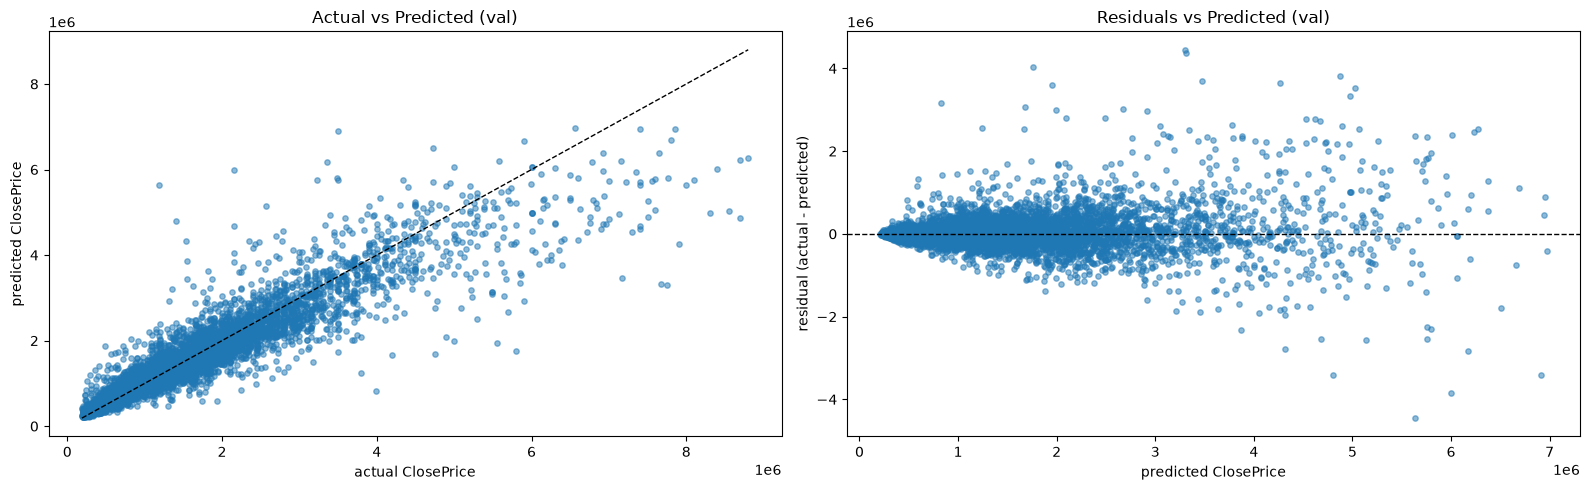

In [31]:
preds = rf_pipeline.predict(X_val)
residuals = y_val - preds

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Actual vs Predicted
axes[0].scatter(y_val, preds, alpha=0.5, s=15)
lims = [min(y_val.min(), preds.min()), max(y_val.max(), preds.max())]
axes[0].plot(lims, lims, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("actual ClosePrice")
axes[0].set_ylabel("predicted ClosePrice")
axes[0].set_title("Actual vs Predicted (val)")

# Residuals vs Predicted
axes[1].scatter(preds, residuals, alpha=0.5, s=15)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("predicted ClosePrice")
axes[1].set_ylabel("residual (actual - predicted)")
axes[1].set_title("Residuals vs Predicted (val)")

plt.tight_layout()
plt.show()

## 6. Comparison and Documented Behavior

Read the table below alongside the reasoning above, not instead of it. A few things worth checking specifically once real numbers are in.

Compare test R squared for all three models against the Linear Regression baseline. Per the project spec, an advanced model needs to beat the baseline by a margin that would survive scrutiny, not by a fraction of a percent that could just be noise.

Compare each model's own train R squared against its own test R squared. Decision Tree is expected to show the largest gap. Random Forest should show a smaller gap than Decision Tree. Linear Regression, having far less capacity to memorize individual rows, should show the smallest gap of the three, though possibly at the cost of a lower ceiling if the true relationship is non-linear.

This comparison is also the input to the next round of feature engineering, not just a scoreboard. If Random Forest clearly beats Linear Regression on test, that is evidence the data contains non-linear structure or feature interactions that Linear Regression cannot represent, which would justify spending effort on the location and temporal features proposed for Week 5 rather than on reshaping the existing ones, since a model that already handles non-linearity should benefit directly from richer raw inputs. If the gap between Random Forest and Linear Regression is small, that instead suggests most of the signal currently available is already linear and already captured, which would push feature engineering toward explicit transforms of existing columns, such as log transforming price or adding interaction terms, rather than only adding new columns and hoping a more flexible model finds the pattern on its own.

In [23]:
comparison_df = pd.DataFrame({
    model_name: {
        "train_r2": metrics["train"]["r2"],
        "val_r2": metrics["val"]["r2"],
        "test_r2": metrics["test"]["r2"],
        "test_mae": metrics["test"]["mae"],
        "test_mape": metrics["test"]["mape"],
        "test_mdape": metrics["test"]["mdape"],
    }
    for model_name, metrics in results.items()
})

comparison_df = comparison_df.T
comparison_df["train_test_r2_gap"] = comparison_df["train_r2"] - comparison_df["test_r2"]
comparison_df

,train_r2,val_r2,test_r2,test_mae,test_mape,test_mdape,train_test_r2_gap
LinearRegression,0.826631,0.822296,0.821687,248883.899745,0.226760,0.161032,0.004944
DecisionTree,0.999950,0.770207,0.782358,232524.240549,0.169051,0.111896,0.217592
RandomForest,0.983597,0.880111,0.876843,169784.611675,0.122388,0.078883,0.106754


# Results


## Key Findings

### **Random Forest achieved the strongest overall predictive performance.**

Random Forest obtained the highest test R² (**0.8768**), improving substantially over the Linear Regression baseline (**0.8217**) while also producing the lowest prediction errors across every reported error metric. Its test MAE decreased by roughly **\$79,000** compared to Linear Regression, and both MAPE and median absolute percentage error were nearly cut in half. These results indicate that the ensemble successfully captures non-linear relationships present in the housing data that cannot be modeled by a simple linear regression. :contentReference[oaicite:1]{index=1}

### **The Decision Tree severely overfit the training data.**

The Decision Tree nearly memorized the training set, achieving an almost perfect training R² (**0.9999**), but its performance dropped considerably on both validation (**0.7702**) and test (**0.7824**) data. This large train-test gap is the classic signature of overfitting and demonstrates poor generalization despite excellent training accuracy. :contentReference[oaicite:2]{index=2} :contentReference[oaicite:3]{index=3}

### **Linear Regression generalized consistently but underfit the data.**

Linear Regression showed almost identical performance across the training, validation, and testing datasets, suggesting very little overfitting. However, its lower R² and noticeably larger prediction errors indicate that the model lacks sufficient flexibility to capture the complex relationships governing housing prices. :contentReference[oaicite:4]{index=4}

### **The comparison provides strong evidence of non-linear structure in the dataset.**

Because Random Forest clearly outperformed the linear baseline rather than improving by only a negligible margin, the results suggest that important feature interactions and non-linear effects exist within the data. This supports further feature engineering efforts focused on richer location- and time-based features, since flexible models are likely to benefit from additional informative inputs. :contentReference[oaicite:5]{index=5}

---

## Overall Conclusion

**Random Forest is the preferred model for the remainder of the project.** It achieved the highest predictive accuracy while maintaining substantially better generalization than a single Decision Tree. The Decision Tree demonstrated the expected overfitting behavior, while Linear Regression provided a stable but less expressive baseline. Overall, the results indicate that housing prices in this dataset exhibit meaningful non-linear relationships, making ensemble tree-based methods the strongest candidate for future modeling and feature engineering.